In [2]:
import pandas as pd
from skimage.io import imread
from skimage.transform import resize
import os
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import load_model


import warnings
warnings.filterwarnings('ignore')

In [3]:
os.listdir(r"C:\Users\ACER\Downloads\Rice_Image_Dataset\train")

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag', 'test']

In [4]:


datadir = r"C:\Users\ACER\Downloads\Rice_Image_Dataset\train"

x_train = []
y_train = []

l = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag', 'test']

IMG_SIZE = 128   # 🔥 reduce size (important)

for i in l:
    path = os.path.join(datadir, i)
    images = os.listdir(path)

    for j in images[:500]:   # 🔥 limit images (important)
        img_path = os.path.join(path, j)

        img_array = cv2.imread(img_path)
        img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

        img_array = img_array.astype('float32') / 255.0

        x_train.append(img_array)
        y_train.append(l.index(i))


In [5]:
os.listdir(r"C:\Users\ACER\Downloads\Rice_Image_Dataset\test")

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag', 'test']

In [6]:
datadir=r"C:\Users\ACER\Downloads\Rice_Image_Dataset\test"

x_test = []
y_test = []

l = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag', 'test']
IMG_SIZE = 128   # 🔥 reduce size (important)

for i in l:
    path = os.path.join(datadir, i)
    images = os.listdir(path)

    for j in images[:500]:   # 🔥 limit images (important)
        img_path = os.path.join(path, j)

        img_array = cv2.imread(img_path)
        img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

        img_array = img_array.astype('float32') / 255.0

        x_test.append(img_array)
        y_test.append(l.index(i))



In [7]:
import numpy as np

In [8]:
x_train=np.array(x_train)
y_train=np.array(y_train)   
x_test=np.array(x_test)
y_test=np.array(y_test)

In [9]:
x_train.shape

(2500, 128, 128, 3)

In [10]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))


In [11]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
model.fit(x_train,y_train,epochs=15,batch_size=20)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.8544 - loss: 0.3769
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.9472 - loss: 0.1389
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.9560 - loss: 0.1211
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9676 - loss: 0.0937
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9692 - loss: 0.0938
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9716 - loss: 0.0820
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.9740 - loss: 0.0699
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9704 - loss: 0.0743
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9812 - loss: 0.0562
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9784 - loss: 0.0593
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - accuracy: 0.9812 - loss: 0.0587
Epoch 12/15
125/125 ━━━━━━━

In [13]:
model.fit(x_test,y_test,epochs=20,batch_size=25)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.9796 - loss: 0.0762
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9808 - loss: 0.0649
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9868 - loss: 0.0549
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9856 - loss: 0.0528
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.9880 - loss: 0.0418
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9868 - loss: 0.0404
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9860 - loss: 0.0458
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9876 - loss: 0.0369
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.9880 - loss: 0.0301
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.9864 - loss: 0.0317
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.9880 - loss: 0.0401
Epoch 12/20
100/100

In [14]:
model.evaluate(x_test,y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9988 - loss: 0.0027


[0.002660346683114767, 0.9987999796867371]

In [15]:
img=imread(r"C:\Users\ACER\Downloads\Rice_Image_Dataset\test\Jasmine\Jasmine (36).jpg")
img

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(250, 250, 3), dtype=uint8)

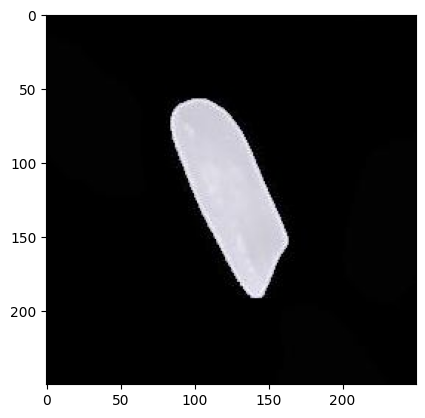

In [16]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [17]:
img.shape


(250, 250, 3)

In [18]:
x_train.shape

(2500, 128, 128, 3)

In [19]:
img = cv2.imread(r"C:\Users\ACER\Downloads\Rice_Image_Dataset\train\Basmati\basmati (67).jpg")
img = cv2.resize(img, (128, 128)) 

In [20]:
img = img.reshape(1, 128, 128, 3)

In [21]:
img.shape

(1, 128, 128, 3)

In [22]:
model.save("rice_model.h5")
model = load_model("rice_model.h5")

In [23]:
pred=model.predict(img)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[0., 1., 0., 0., 0., 0.]], dtype=float32)

In [24]:
index=pred.argmax(axis=1)
index

array([1])

In [25]:
l[index.item()]

'Basmati'

In [26]:
if index == 0:
    print("The rice type is Arborio .")
elif index == 1:
    print("The rice type is Basmati.")
elif index == 2:
    print("The rice type is Ipsala.")
elif index == 3:
    print("The rice type is Jasmine.")
elif index == 4:
    print("The rice type is Karacadag.")
else:
    print("Model is not able to predict the rice type. Check the image and try again.")

The rice type is Basmati.
